In [1]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pickle
from matplotlib.colors import ListedColormap

## Problem: PO

Given $N$ stocks and a fixed bugdet to spend, what are the portions of the budget to assign to each stock to maximise return $\mu$ while minimizing the risk $\Sigma$? The granularity is a parameter $w$.

The Quadratic Unconstrained INTEGER Optimization model can be formulated in the following way

\begin{align}
	H = \sum_{i, j=1}^{N} (\gamma  \Sigma_{i,j} - \delta_{ij}\mu_{i}) \tilde x_{i} \tilde x_{j}  + M \bigg[ \sum_{i=1}^{N} \tilde x_i - (2^w - 1)  \bigg]^2\, ,
\end{align}

where $\gamma$ is the risk aversion factor, the decision variable $\tilde x \in \{0, \cdots, 2^w-1\}^N$ is a vector of integers, one for each stock, that indicates how many equal portions of the $2^w-1$ to invest in each stock. The constraint enforces that the total portions of the stocks sum up to $2^w - 1$.

In order to be mapped to a binary problem, each integer variable $\tilde x_i \in \{0, \cdots, 2^w-1\}$ can be expressed using $w$ bits via: $\tilde x_i = \sum_{k = 0}^{w-1} 2^k x^{(i)}_k$.

In the QUBO reformulation, if we want to keep just the binary variables as bits while incorporating the powers of $2$ in the problem matrix, we can rewrite them in the following way. Only for the return $\mu$ will be showed for semplicity: we want to go from $\mu_{(int)} \in \mathbb R ^N \to \mu_{(bin)} \in \mathbb R ^{wN}$. First we repeat $w$ times each entry of $\mu_{(int)}$, then we entry-wise multiply it by the scaler $A = N \textit{ times }[2^{w-1}, 2^{w-2}, \cdots, 2^1, 2^0]$, to get in the end $\mu_{(bin)} = [2^{w-1} \mu_{(int)}[0], 2^{w-2} \mu_{(int)}[0], \cdots, 2^0 \mu_{(int)}[0], 2^{w-1} \mu_{(int)}[1], \cdots, \cdots, 2^{0} \mu_{(int)}[N-1]]$.


- $N$: Number of stocks.
- $w$: Granularity: each ratio can be described to a precision of $(2^w-1)^{-1}$, and you need $w$ qubits per stock
- ${\rm{bits}} = Nw*$: Number of bits needed to represent problem QUBO.
- $M$: Penalty factor.


Expanding the Hamiltonians $H = H_o + M H_p$, using now BINARY variables, the Quadratic Unconstrained Binary Optimization model can be formulated in the following way, where $A_{(bin)} \in \mathbb N ^{wN}, \;\mu_{(bin)} \in \mathbb R ^{wN}, \; \Sigma_{(bin)} \in \mathbb R ^{wN \times wN}$ and we characterized the constraints elements $A_{(bin)i} = 2^{w - 1 - i\%w}$, $b = 2^w - 1$, so that the constraint can be expressed as $Ax = b$.

$$
H_o =  \sum_{i, j=1}^{Nw}  (\gamma  \Sigma_{(bin)i,j} - \delta_{ij}\mu_{(bin)i}) x_{i}x_{j}
$$

$$
H_p = \bigg[ \sum_{i=1}^{N} \tilde x_i - b  \bigg]^2 = b^2 + \sum_{i}^{Nw} \biggl(-2 b A_{(bin)i} \biggr)x_{i} + \sum_{i, j}^{Nw} A_{(bin)i} A_{(bin)j} x_i x_j
$$

In [2]:
### nice plots

import matplotlib as matp

matp.rcParams['mathtext.fontset'] = 'stix'
matp.rcParams['font.family'] = 'STIXGeneral'

## Read data for analysis

In [3]:
class Datas():
    def __init__(self, bits_idx_list, n_temp_scalers, M_strats, n_eta_runs):
        N_stocks = np.array([2, 4, 6, 8, 10, 15, 20, 30, 40, 50, 60])
        self.w = 5
        self.directory = "PO_big"
        vseeds = range(42, 343, 100)

        self.Ns = N_stocks[bits_idx_list]
        self.bits = self.Ns[bits_idx_list] * self.w
        self.vseeds = vseeds
        self.n_vseeds = len(vseeds)
        self.M_strategies = M_strats # index: 0->"feasibility", 1->"optimality"
        self.temperature_scalers = [1, 10, 100]
        self.SA_samples = 1000

        self.M_star = np.ndarray((len(bits_idx_list), len(vseeds), n_temp_scalers, len(M_strats), n_eta_runs))
        self.M_L1 = np.ndarray((len(bits_idx_list), len(vseeds), n_temp_scalers, len(M_strats), n_eta_runs))
        self.eta_required = np.ndarray((len(bits_idx_list), len(vseeds), n_temp_scalers, len(M_strats), n_eta_runs))
        self.eta_guaranteed = np.ndarray((len(bits_idx_list), len(vseeds), n_temp_scalers, len(M_strats), n_eta_runs))
        self.eta_effective = np.ndarray((len(bits_idx_list), len(vseeds), n_temp_scalers, len(M_strats), n_eta_runs))
        self.temperature = np.ndarray((len(bits_idx_list), len(vseeds), n_temp_scalers, 2)) # last index: 0->initial, 1->final
        self.E_f = np.ndarray((len(bits_idx_list), len(vseeds)))

In [4]:
# change last_Nidx to extend your dataset as you collect more data

last_Nidx = 8
N_stocks = np.array([2, 4, 6, 8, 10, 15, 20, 30, 40, 50, 60])
N_idxs = np.arange(last_Nidx+1)
n_temp_scalers = 3
M_strategies = ["feasibility", "optimality"]
n_eta_runs = 3
data = Datas(N_idxs, n_temp_scalers, M_strategies, n_eta_runs)

directory = "../data/SA_PO/"

for N_idx in N_idxs: # if N_idxs start from 0. Else, write "for N_idx_idx, N_idx in enumerate(N_idxs):"
    filename = directory + f"results-N={N_stocks[N_idx]}_w={data.w}.txt"
    file = open(filename, "rb")
    D = pickle.load(file)
    file.close()

    assert len(D.keys()) == len(data.vseeds)
    for seed_idx, seed in enumerate(D):
        data.E_f[N_idx, seed_idx] = D[seed]["E_f"]

        assert len(D[seed].keys()) == n_temp_scalers + 1 # the +1 is for E_f
        for temp_idx, temp_scaler in enumerate(list(D[seed])[1:]):
            data.temperature[N_idx, seed_idx, temp_idx, 0] = D[seed][temp_scaler]["temp_initial"]
            data.temperature[N_idx, seed_idx, temp_idx, 1] = D[seed][temp_scaler]["temp_final"]

            assert len(D[seed][temp_scaler].keys()) == len(M_strategies) + 2  # the +2 is for temperature final and initial
            for M_strat_idx, M_strat in enumerate(list(D[seed][temp_scaler])[2:]):
                assert len(D[seed][temp_scaler][M_strat].keys()) == n_eta_runs
                for eta_run_idx, eta_req in enumerate(D[seed][temp_scaler][M_strat]):
                    data.M_star[N_idx, seed_idx, temp_idx, M_strat_idx, eta_run_idx] = D[seed][temp_scaler][M_strat][eta_req]["M_star"]
                    data.M_L1[N_idx, seed_idx, temp_idx, M_strat_idx, eta_run_idx] = D[seed][temp_scaler][M_strat][eta_req]["M_L1"]
                    data.eta_required[N_idx, seed_idx, temp_idx, M_strat_idx, eta_run_idx] = D[seed][temp_scaler][M_strat][eta_req]["eta_required"]
                    data.eta_guaranteed[N_idx, seed_idx, temp_idx, M_strat_idx, eta_run_idx] = D[seed][temp_scaler][M_strat][eta_req]["eta_guaranteed"]
                    data.eta_effective[N_idx, seed_idx, temp_idx, M_strat_idx, eta_run_idx] = D[seed][temp_scaler][M_strat][eta_req]["eta_effective"]

## $\eta_{eff} / \eta_{guar} (\beta_f scaler)$ for different $\eta_{req}$ and feas/opt $M$ strategies

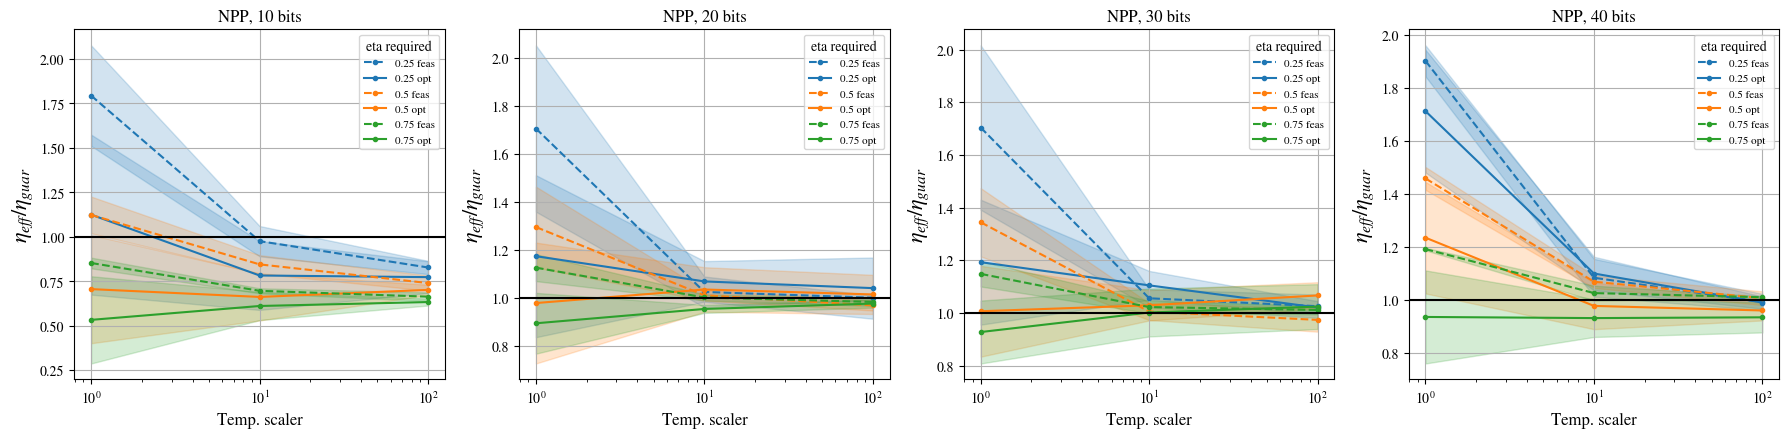

In [15]:
fig = plt.figure(figsize=(22,10))

for N_idx in N_idxs:
    ratios = np.mean( data.eta_effective[N_idx, ...] / data.eta_guaranteed[N_idx, ...] , axis = 0)
    ratios_std = np.std( data.eta_effective[N_idx, ...] / data.eta_guaranteed[N_idx, ...] , axis = 0)
    
    ax = fig.add_subplot(2,4,N_idx+1)
    ax.set_xlabel('Temp. scaler', fontsize = 12)
    ax.set_ylabel(r'$\eta_{eff} / \eta_{guar}$', fontsize = 16)

    for eta_run_idx in np.arange(n_eta_runs):
        ax.plot(data.temperature_scalers, ratios[:, 0, eta_run_idx], "--", marker = ".", color = f"C{eta_run_idx}", label=str(data.eta_required[N_idx, 0, 0, 0, eta_run_idx]) + " feas")
        ax.plot(data.temperature_scalers, ratios[:, 1, eta_run_idx], "-", marker = ".", color = f"C{eta_run_idx}", label=str(data.eta_required[N_idx, 0, 0, 0, eta_run_idx]) + " opt")
        ax.fill_between(data.temperature_scalers, ratios[:, 0, eta_run_idx] - ratios_std[:, 0, eta_run_idx], ratios[:, 0, eta_run_idx] + ratios_std[:, 0, eta_run_idx], color = f"C{eta_run_idx}", alpha=.2)
        ax.fill_between(data.temperature_scalers, ratios[:, 1, eta_run_idx] - ratios_std[:, 1, eta_run_idx], ratios[:, 1, eta_run_idx] + ratios_std[:, 1, eta_run_idx], color = f"C{eta_run_idx}", alpha=.2)
    ax.set_xscale("log")
    ax.set_title(f"NPP, {data.Ns[N_idx] * data.w} bits")
    ax.axhline(1, color = "k")
    ax.legend(title = "eta required", fontsize = 8, loc='best')
    ax.grid()
plt.show()

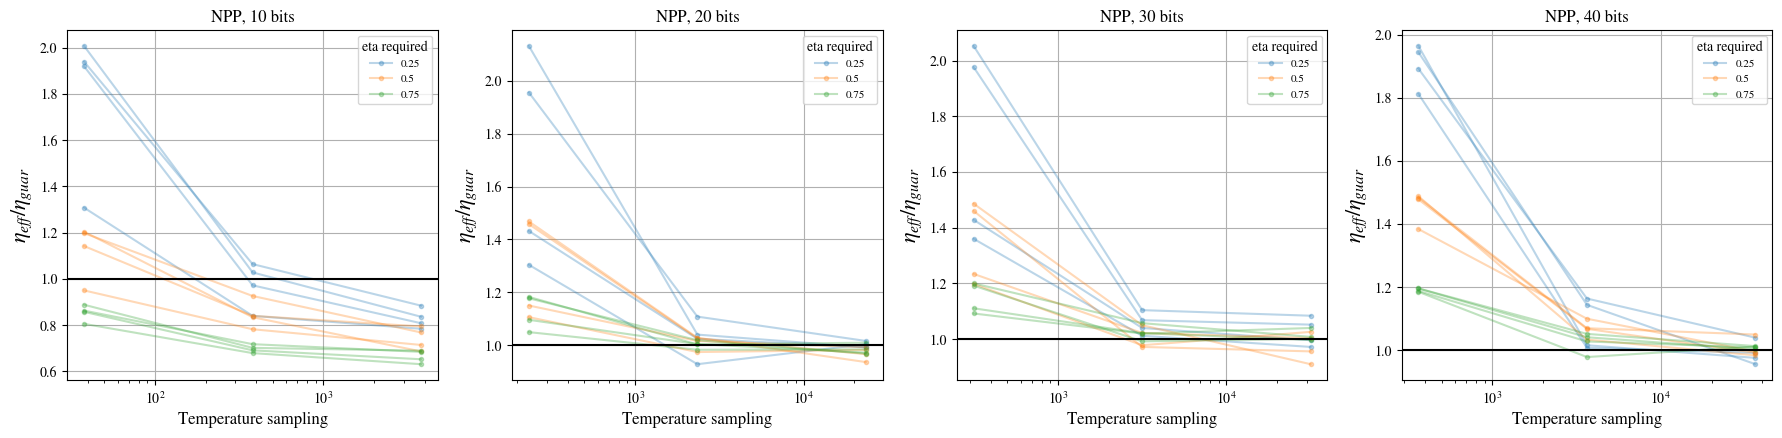

In [17]:
Mstrat = 0

fig = plt.figure(figsize=(22,10))
for N_idx in N_idxs:
    ratios = data.eta_effective[N_idx, :, :, Mstrat, :] / data.eta_guaranteed[N_idx, :, :, Mstrat, :] # [seed_idx, temp_idx, eta_run_idx]
    ax = fig.add_subplot(2,4,N_idx+1)
    ax.set_xlabel('Temperature sampling', fontsize = 12)
    ax.set_ylabel(r'$\eta_{eff} / \eta_{guar}$', fontsize = 16)

    for eta_run_idx in np.arange(n_eta_runs):
        for seed_idx in np.arange(data.n_vseeds):
            if seed_idx == 0:
                ax.plot(data.temperature[N_idx, seed_idx, :, 1], ratios[seed_idx, :, eta_run_idx], "-", marker = ".", color = f"C{eta_run_idx}", label=str(data.eta_required[N_idx, 0, 0, 0, eta_run_idx]), alpha = 0.3)
            else:
                ax.plot(data.temperature[N_idx, seed_idx, :, 1], ratios[seed_idx, :, eta_run_idx], "-", marker = ".", color = f"C{eta_run_idx}", alpha = 0.3)
    ax.set_xscale("log")
    ax.set_title(f"NPP, {data.Ns[N_idx] * data.w} bits")
    ax.axhline(1, color = "k")
    ax.legend(title = "eta required", fontsize = 8, loc='best')
    ax.grid()
plt.show()

## $\eta_{eff} / \eta_{guar} (n_{bits})$

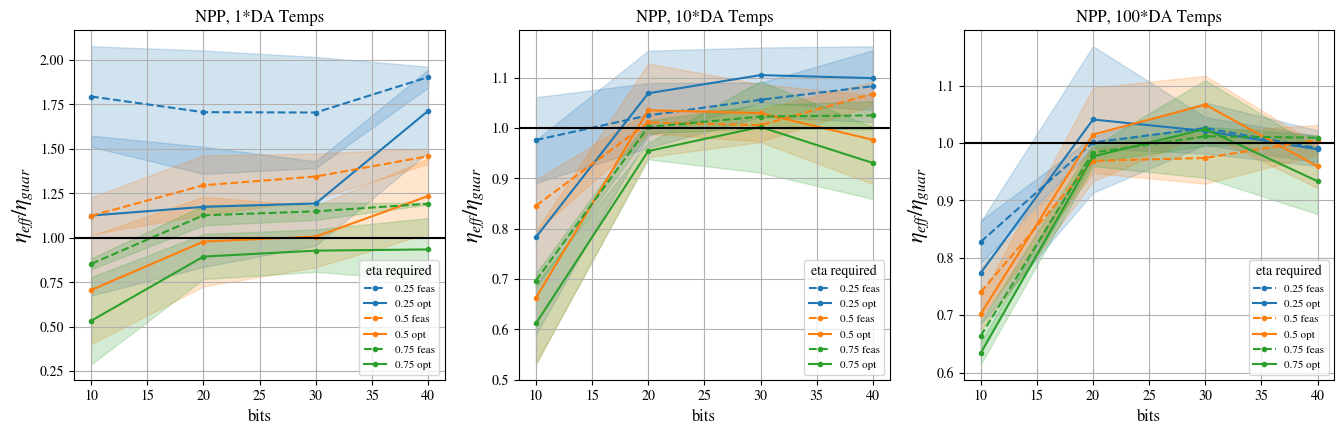

In [18]:
fig = plt.figure(figsize=(22,10))
for temp_idx in range(n_temp_scalers):
    ratios = np.mean( data.eta_effective[:, :, temp_idx, ...] / data.eta_guaranteed[:, :, temp_idx, ...] , axis = 1)
    ratios_std = np.std( data.eta_effective[:, :, temp_idx, ...] / data.eta_guaranteed[:, :, temp_idx, ...] , axis = 1)
    
    ax = fig.add_subplot(2,4,temp_idx+1)
    ax.set_xlabel('bits', fontsize = 12)
    ax.set_ylabel(r'$\eta_{eff} / \eta_{guar}$', fontsize = 16)

    for eta_run_idx in np.arange(n_eta_runs):
        ax.plot(data.bits, ratios[:, 0, eta_run_idx], "--", marker = ".", color = f"C{eta_run_idx}", label=str(data.eta_required[N_idx, 0, 0, 0, eta_run_idx]) + " feas")
        ax.plot(data.bits, ratios[:, 1, eta_run_idx], "-", marker = ".", color = f"C{eta_run_idx}", label=str(data.eta_required[N_idx, 0, 0, 0, eta_run_idx]) + " opt")
        ax.fill_between(data.bits, ratios[:, 0, eta_run_idx] - ratios_std[:, 0, eta_run_idx], ratios[:, 0, eta_run_idx] + ratios_std[:, 0, eta_run_idx], color = f"C{eta_run_idx}", alpha=.2)
        ax.fill_between(data.bits, ratios[:, 1, eta_run_idx] - ratios_std[:, 1, eta_run_idx], ratios[:, 1, eta_run_idx] + ratios_std[:, 1, eta_run_idx], color = f"C{eta_run_idx}", alpha=.2)
    #ax.set_xscale("log")
    ax.set_title(f"NPP, {data.temperature_scalers[temp_idx]}*DA Temps")
    ax.axhline(1, color = "k")
    ax.legend(title = "eta required", fontsize = 8, loc='best')
    ax.grid()
plt.show()

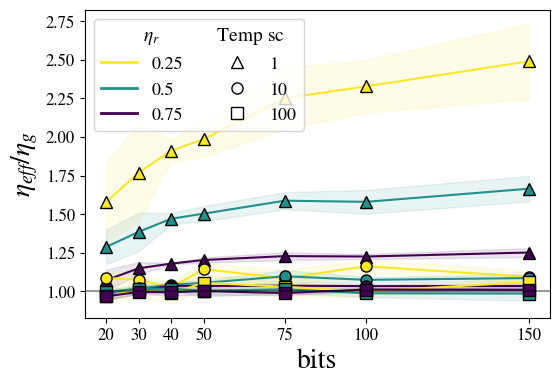

In [84]:
M_strategy = "optimality" # "feasibility" or "optimality"
if M_strategy == "feasibility":
    M_strat_idx = 0
    M_strat_short = "feas"
else:
    M_strat_idx = 1
    M_strat_short = "opt"

to_skip = 1

markers = ["^", "o", "s"]
colormap = plt.cm.viridis.reversed()
discr_colors = ListedColormap(colormap(np.linspace(0, 1, n_temp_scalers))) 

fig = plt.figure(figsize=(6,4))
ax = fig.add_subplot(111)
ax.set_xlabel(r'bits', fontsize = 20)
ax.set_ylabel(r'$\eta_{eff} / \eta_{g}$', fontsize = 20)
ax.set_xticks(data.bits)
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12) 

for temp_idx in range(n_temp_scalers):
    ratios = np.mean( data.eta_effective[:, :, temp_idx, ...] /  data.eta_guaranteed[:, :, temp_idx, ...], axis = 1)
    ratios_std = np.std( data.eta_effective[:, :, temp_idx, ...] /  data.eta_guaranteed[:, :, temp_idx, ...], axis = 1)
    for eta_run_idx in np.arange(n_eta_runs):
        ax.plot(data.bits[to_skip:], ratios[to_skip:, M_strat_idx, eta_run_idx], "-", marker = markers[temp_idx], markersize = 8, color = discr_colors.colors[eta_run_idx], markeredgecolor="black",
                        label=str(data.eta_required[N_idx, 0, 0, 0, eta_run_idx]) + f" ; {data.temperature_scalers[temp_idx]}")
        ax.fill_between(data.bits[to_skip:], ratios[to_skip:, M_strat_idx, eta_run_idx] - ratios_std[to_skip:, M_strat_idx, eta_run_idx], ratios[to_skip:, M_strat_idx, eta_run_idx] + ratios_std[to_skip:, M_strat_idx, eta_run_idx],
                        color = discr_colors.colors[eta_run_idx], alpha=.1)

# ---- Concise legend ----
eta_handles = [Line2D([0], [0], color=c, lw=2, label=f'{eta}') for c, eta in zip(discr_colors.colors, data.eta_required[0,0,0,0])]
temp_handles = [Line2D([0], [0], color="w", markersize = 8,  markeredgecolor = "k", marker=m, lw=0, label=T) for m, T in zip(markers, data.temperature_scalers)]
all_handles = eta_handles + temp_handles
all_labels  = [h.get_label() for h in all_handles]
ax.legend(handles=all_handles, labels=all_labels, title=r"      $\eta_{r}$            Temp sc", title_fontsize=14, fontsize=13, loc="best", ncol=2)
# --------

#ax.legend(title = r"$\eta$ required ; $\beta$ scaler", fontsize = 10, loc='center right')
#ax.grid()
if M_strategy == "feasibility":
    ax.set_title("PO", fontsize = "18")
ax.axhline(1, color = "k", alpha = 0.4)

plt.show()

# fig.savefig(f"../plots_paper/eta_ratio/Gibbs_PO_{M_strat_short}.pdf", bbox_inches='tight', format="pdf")

## $\eta_{eff} (n_{bits})$

In [5]:
def plot_marker_whiskers(ax, data, indexes):
    draw_lower_whiskers, draw_upper_whiskers = True, False

    xs = data.bits[to_skip:]
    indexes = temp_idx, M_strat_idx, eta_run_idx
    eta_r = data.eta_required[to_skip:, 0, temp_idx, M_strat_idx, eta_run_idx]
    y = np.mean( data.eta_effective[to_skip:, :, temp_idx, M_strat_idx, eta_run_idx], axis = 1)
    ax.plot(xs, y, linestyle="None", marker = markers[temp_idx], markersize = 8, color = discr_colors.colors[eta_run_idx], markeredgecolor="black")

    # compute where to draw whiskers
    condition_eff =  y  <  eta_r
    condition_gua =  np.mean(data.eta_guaranteed[to_skip:, :, temp_idx, M_strat_idx, eta_run_idx], axis = 1)  <  eta_r
    mask_whisk = np.logical_and(condition_gua, condition_eff)
    # compute whiskers lengths from eta_guaranteed
    whisk = y[mask_whisk] - np.mean(data.eta_guaranteed[to_skip:, :, temp_idx, M_strat_idx, eta_run_idx], axis = 1)[mask_whisk]
    whisk_down = np.where(whisk > 0, whisk, 0)
    whisk_up = np.where(whisk < 0, -whisk, 0)

    capsize = .5
    cap_thickness = 1.5    
    # draw only lower whiskers manually
    if draw_lower_whiskers:
        for xi, yi, yd in zip(xs[mask_whisk], y[mask_whisk], whisk_down):
            ax.vlines(xi, yi - yd, yi, color=discr_colors.colors[eta_run_idx], lw=cap_thickness)
            ax.hlines(yi - yd, xi - capsize, xi + capsize, color=discr_colors.colors[eta_run_idx], lw=cap_thickness)
    # draw only upper whiskers manually
    if draw_upper_whiskers:
        for xi, yi, yd in zip(xs[mask_whisk], y[mask_whisk], whisk_up):
            ax.vlines(xi, yi, yi + yd, color=discr_colors.colors[eta_run_idx], lw=cap_thickness)
            ax.hlines(yi + yd, xi - capsize, xi + capsize, color=discr_colors.colors[eta_run_idx], lw=cap_thickness)
    return

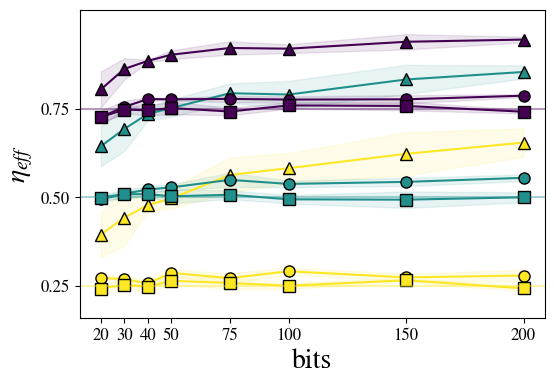

In [ ]:
M_strategy = "optimality" # "feasibility" or "optimality"
if M_strategy == "feasibility":
    M_strat_idx = 0
    M_strat_short = "feas"
else:
    M_strat_idx = 1
    M_strat_short = "opt"

to_skip = 1
markers = ["^", "o", "s"]
colormap = plt.cm.viridis.reversed()
discr_colors = ListedColormap(colormap(np.linspace(0, 1, n_temp_scalers))) 

fig = plt.figure(figsize=(6,4))
ax = fig.add_subplot(111)
ax.set_xlabel(r'bits', fontsize = 20)
ax.set_ylabel(r'$\eta_{eff}$', fontsize = 20)
ax.set_xticks(data.bits)
ax.set_yticks([.25, .5, .75])
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12) 
ax.set_ylim(.16, 1.03)

for temp_idx in range(n_temp_scalers):
    for eta_run_idx in np.arange(n_eta_runs):
        y = np.mean( data.eta_effective[to_skip:, :, temp_idx, M_strat_idx, eta_run_idx], axis = 1)
        y_std = np.std( data.eta_effective[to_skip:, :, temp_idx, M_strat_idx, eta_run_idx], axis = 1)
        # lines and shades
        ax.plot(data.bits[to_skip:], y, "-", color = discr_colors.colors[eta_run_idx], label=str(data.eta_required[N_idx, 0, 0, 0, eta_run_idx]) + f" ; {data.temperature_scalers[temp_idx]}")
        ax.fill_between(data.bits[to_skip:], y - y_std, y + y_std, color = discr_colors.colors[eta_run_idx], alpha=.1)
        # dots
        plot_marker_whiskers(ax, data, (temp_idx, M_strat_idx, eta_run_idx))

# # ---- Concise legend ----
# eta_handles = [Line2D([0], [0], color=c, lw=2, label=f'{eta}') for c, eta in zip(discr_colors.colors, data.eta_required[0,0,0,0])]
# temp_handles = [Line2D([0], [0], color="w", markersize = 8,  markeredgecolor = "k", marker=m, lw=0, label=T) for m, T in zip(markers, data.temperature_scalers)]
# all_handles = eta_handles + temp_handles
# all_labels  = [h.get_label() for h in all_handles]
# ax.legend(handles=all_handles, labels=all_labels, title=r"      $\eta_{r}$            Temp.", title_fontsize=14, fontsize=13, loc="best", ncol=2)
# # --------

if M_strategy == "feasibility":
    ax.set_title("PO", fontsize = "18")
eta_req_tmp = [.25, .5, .75]
for i in range(len(eta_req_tmp)):
    ax.axhline(eta_req_tmp[i], color = discr_colors.colors[i], alpha = 0.4)
plt.show()

# fig.savefig(f"../plots_paper/eta_eff/SA_PO_{M_strat_short}.pdf", bbox_inches='tight', format="pdf")

## $log( M_{\ell_1} / M^*)(n_{bits})$ for different temperatures

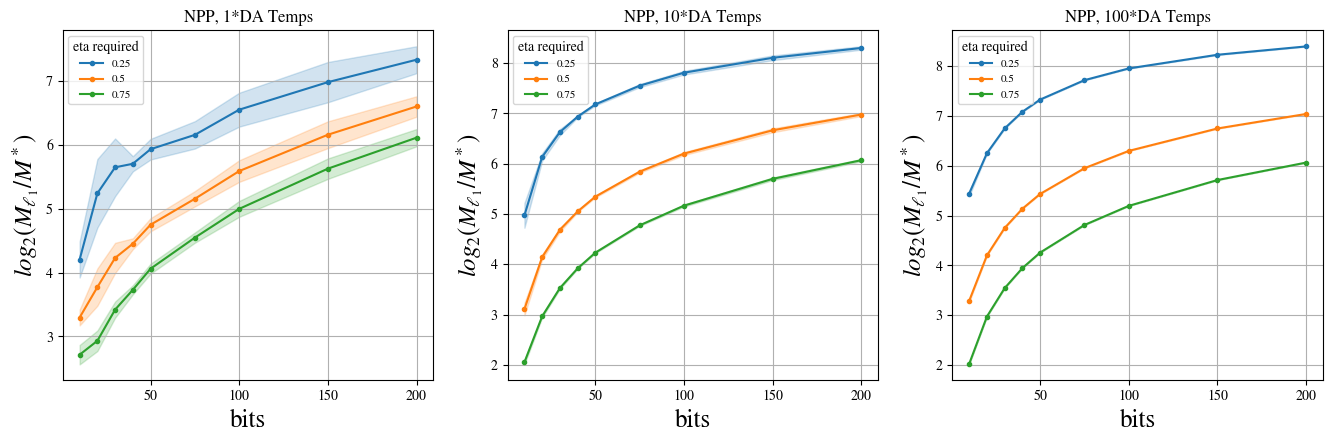

In [5]:
Mstrat = 0

fig = plt.figure(figsize=(22,10))
for temp_idx in range(n_temp_scalers):
    logs = np.mean(  np.log2(data.M_L1[:, :, temp_idx, Mstrat, ...] / data.M_star[:, :, temp_idx, Mstrat, ...])  , axis = 1)
    logs_std = np.std(  np.log2(data.M_L1[:, :, temp_idx, Mstrat, ...] / data.M_star[:, :, temp_idx, Mstrat, ...]) , axis = 1)
    
    ax = fig.add_subplot(2,4,temp_idx+1)
    ax.set_xlabel('bits', fontsize = 18)
    ax.set_ylabel(r'$log_2( M_{\ell_1} / M^*)$', fontsize = 18)

    for eta_run_idx in np.arange(n_eta_runs):
        ax.plot(data.bits, logs[:, eta_run_idx], "-", marker = ".", color = f"C{eta_run_idx}", label=str(data.eta_required[N_idx, 0, 0, 0, eta_run_idx]))
        ax.fill_between(data.bits, logs[:, eta_run_idx] - logs_std[:, eta_run_idx], logs[:, eta_run_idx] + logs_std[:, eta_run_idx], color = f"C{eta_run_idx}", alpha=.2)
    #ax.set_xscale("log")
    ax.set_title(f"NPP, {data.temperature_scalers[temp_idx]}*DA Temps")
    ax.legend(title = "eta required", fontsize = 8, loc='best')
    ax.grid()
plt.show()

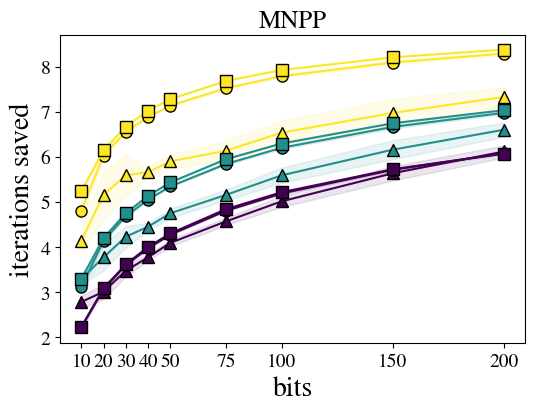

In [8]:
Mstrat = 0

markers = ["^", "o", "s"]
colormap = plt.cm.viridis.reversed()
discr_colors = ListedColormap(colormap(np.linspace(0, 1, n_eta_runs))) 

### NOTE: due to erroneous calculation of thermal M_L1 (\eta rather than 1-\eta), the eta_index is reversed to plot the orrect quantities.
### However, after collecting the plot, correct this erroneous data in the file saved directly
mod_M_L1 = data.M_L1[..., ::-1]


fig = plt.figure(figsize=(6,4))
ax = fig.add_subplot(111)
ax.set_xlabel(r'bits', fontsize = 20)
#ax.set_ylabel(r'$log_2( M_{\ell_1} / M^*)$', fontsize = 20)
ax.set_ylabel(r'iterations saved', fontsize = 20)
ax.tick_params(axis='both', labelsize=14)
ax.set_xticks(data.bits)
for temp_idx in range(n_temp_scalers):
    for eta_run_idx in np.arange(n_eta_runs):
        logs = np.mean(  np.log2(mod_M_L1[:, :, temp_idx, Mstrat, eta_run_idx] / data.M_star[:, :, temp_idx, Mstrat, eta_run_idx])  , axis = 1)
        logs_std = np.std(  np.log2(mod_M_L1[:, :, temp_idx, Mstrat, eta_run_idx] / data.M_star[:, :, temp_idx, Mstrat, eta_run_idx]) , axis = 1)
        ax.plot(data.bits, logs, "-", color = discr_colors.colors[eta_run_idx], marker = markers[temp_idx], markersize = 8, markeredgecolor="k",
                 label=str(data.eta_required[N_idx, 0, 0, 0, eta_run_idx]) + f" ; {data.temperature_scalers[temp_idx]}")
        ax.fill_between(data.bits, logs - logs_std, logs + logs_std, color = discr_colors.colors[eta_run_idx], alpha=.1)

# # ---- Concise legend ----
# eta_handles = [Line2D([0], [0], color=c, lw=2, label=f'{eta}') for c, eta in zip(discr_colors.colors, data.eta_required[0,0,0,0])]
# temp_handles = [Line2D([0], [0], color="w", markersize = 8,  markeredgecolor = "k", marker=m, lw=0, label=T) for m, T in zip(markers, data.temperature_scalers)]
# all_handles = eta_handles + temp_handles
# all_labels  = [h.get_label() for h in all_handles]## $log( M_{\ell_1} / M^*)(n_{bits})$ in a single plot
# ax.legend(handles=all_handles, labels=all_labels, title=r"      $\eta_{r}$            $T/T_{DA}$", title_fontsize=14, fontsize=13, loc="best", ncol=2)
# # --------
# ax.set_xscale("log")
ax.set_title(f"MNPP", fontsize = 18)
plt.show()

# fig.savefig("../plots/iters_saved/Gibbs_MNPP.pdf", bbox_inches='tight', format="pdf")